# Hopefully Final

## Packages

In [ ]:
# Data Cleaning
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Selection (sklearn)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Model Selection & Validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Metrics
from sklearn.metrics import(
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model Analysis & Interpretation
from sklearn.utils import resample
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)


## Data Cleaning

In [3]:
dataset=pd.read_csv("dataset.csv", index_col=0)
outcome=pd.read_csv("outcome.csv", index_col=0)

In [4]:
#sets zusammenfügen
combined=dataset.join(outcome)

In [5]:
#wie viele werte fehlen in diesem Dataset
combined.isna().sum(axis=1).sum()

np.int64(275)

In [6]:
#wie viele Werte fehlen wo
combined.isna().sum(axis=0).sort_values(ascending=False)

BRCA_subtype    262
FGFR1OP2          5
RNF13             4
ATRX              4
PLIN3             0
               ... 
C16orf11          0
PLIN5             0
TSKS              0
IGFN1             0
PMM2              0
Length: 16384, dtype: int64

In [7]:
#alle Subtypen mit Nan entfernen 
combined_clean=combined.dropna(subset=["BRCA_subtype"])

In [8]:
#kontrolle wie viele noch übrig nachdem zeilen Subtyp=nan noch übrig
remaining_nans = combined_clean.isna().sum()

In [9]:
# Entferne die restlichen NaNs
combined_clean = combined_clean.dropna()

In [10]:
#kontrolle ob alle Nans weg
print(combined_clean.isna().sum().sum())

0


### Imbalance beweisen

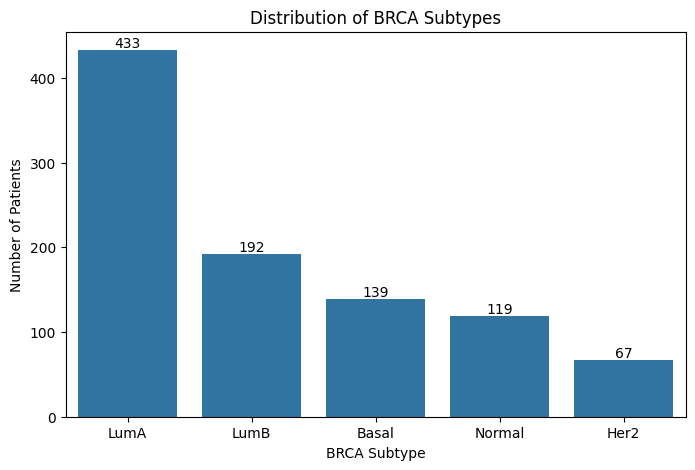

In [11]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=combined_clean, #weil die patienten ohne NaN nichts aussagen
    x="BRCA_subtype",
    order=combined_clean["BRCA_subtype"].value_counts().index
)

# Zahlen über Balken schreiben
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of BRCA Subtypes")
plt.xlabel("BRCA Subtype")
plt.ylabel("Number of Patients")

plt.show()

### Varianzen prüfen

In [12]:
# Features und Label trennen
X = combined_clean.drop(columns=["BRCA_subtype"])
y = combined_clean["BRCA_subtype"]

In [13]:
# Varianz jedes Gens berechnen
variances = X.var()

In [14]:
# Statistische Übersicht
print(variances.describe())

count    16383.000000
mean         1.239637
std          1.742989
min          0.000000
25%          0.279232
50%          0.595600
75%          1.528650
max         37.376686
dtype: float64


| Statistik       | Bedeutung                                       |
| --------------- | ----------------------------------------------- |
| `count = 16383` | so viele Gene/Fatures habt ihr                  |
| `min = 0`       | mindestens ein Gen hat exakt keine Varianz      |
| `25% = 0.279`   | 25 % aller Gene haben Varianz kleiner als 0.279 |
| `50% = 0.596`   | Medianvarianz                                   |
| `75% = 1.529`   | obere 25 % sind deutlich variabler              |
| `max = 37.37`   | einige Gene variieren extrem stark              |


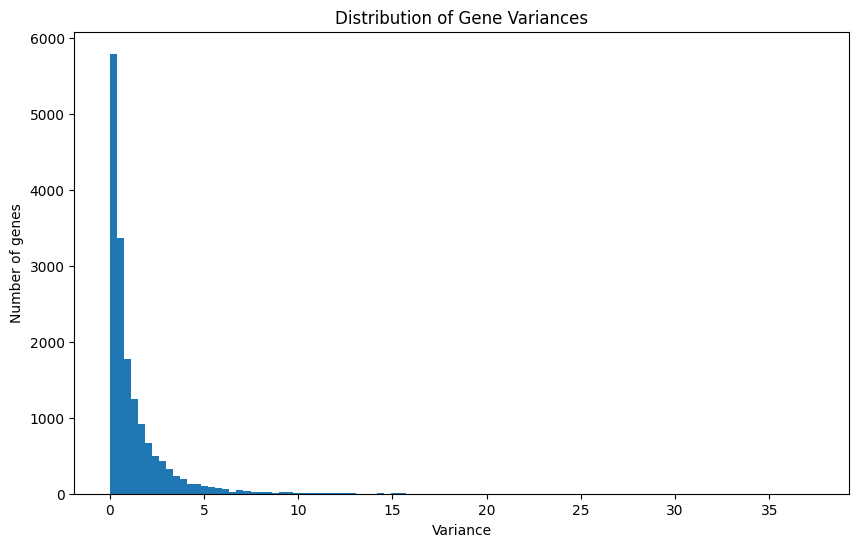

In [15]:
# Histogramm der Varianzen
plt.figure(figsize=(10,6))
plt.hist(variances, bins=100)

plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of Gene Variances")

plt.show()

In [16]:
overview = pd.DataFrame({
    "variable": combined_clean.columns,
    "dtype": combined_clean.dtypes.astype(str).values,
    "n_unique": [combined_clean[col].nunique() for col in combined_clean.columns]
})

display(overview)


,variable,dtype,n_unique
0,ARHGEF10L,float64,931
1,HIF3A,float64,911
2,RNF17,float64,219
3,RNF10,float64,906
4,RNF11,float64,925
...,...,...,...
16379,HCG27,float64,934
16380,CYP2A13,float64,342
16381,CCR10,float64,937
16382,KDM4D,float64,932


In [17]:
#Standardabweichung / Varianz prüfen
gene_std = combined_clean.drop(columns="BRCA_subtype").std()
#.std(): Berechnet std : Wie stark streuuen die Werte um den Mittelwert
gene_std.sort_values().head(20)

#Output=0: überhaupt keine Streuung --> Alle Patienten haben exakt denselben Wert für dieses Gen --> Keine hilfreiche Info

SNORD113-4     0.0
TXNDC8         0.0
RBMY1A3P       0.0
SNORD88B       0.0
TTTY3B         0.0
SNORD115-2     0.0
SNORD115-3     0.0
SNORD116-13    0.0
TTTY6B         0.0
DAZ4           0.0
SNORD60        0.0
SNORD115-11    0.0
SNORD44        0.0
TSSK2          0.0
LOC653545      0.0
SNORD105       0.0
SNORD91A       0.0
SNAR-D         0.0
SNORA11C       0.0
SNORD115-16    0.0
dtype: float64

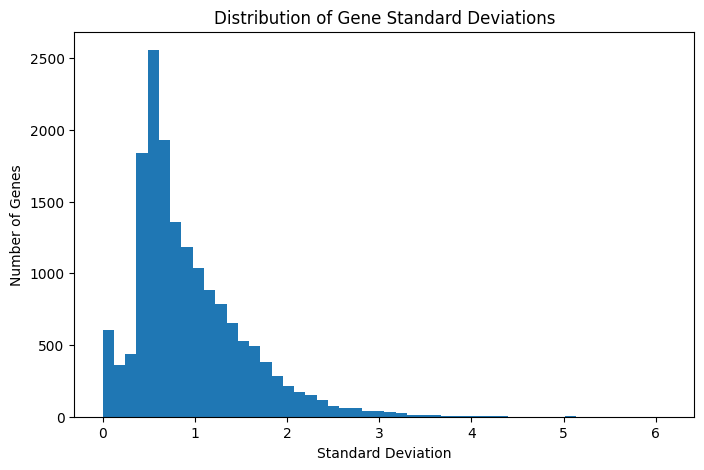

In [18]:
#Histogramm der Standardabweichungen
gene_std = combined_clean.drop(columns="BRCA_subtype").std()

plt.figure(figsize=(8,5))
plt.hist(gene_std, bins=50)
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene Standard Deviations")
plt.show()

In [19]:
#Um alle Gene mit n_unique = 1 zu sehen (also konstante Features), filterst du einfach dein overview-DataFrame:
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [20]:
# nur die Namen der Gene 
constant_gene_names = constant_features["variable"].tolist()

print(constant_gene_names)

['RBMY1A3P', 'SNORD115-17', 'SNORD114-31', 'SNORD114-30', 'SNORD115-6', 'SNORD115-4', 'SNORD104', 'SNORD115-9', 'SNORD38A', 'KRTAP19-7', 'KRTAP19-4', 'SNORD114-3', 'HBII-52-27', 'SNORD11', 'SNORD12', 'SNORD21', 'SNORD20', 'SNORD25', 'SNORD127', 'DAZ3', 'DAZ2', 'DAZ4', 'SNORD124', 'TTTY17A', 'SNORD115-5', 'SNORD80', 'SNORD56B', 'SNORD78', 'SNORD113-7', 'SNORD96A', 'SNORD119', 'HBII-52-46', 'HBII-52-45', 'SNORD47', 'SNORD4B', 'SNORD4A', 'SNORD116-24', 'SNORD116-25', 'SNORD116-23', 'SNORD116-29', 'RBMY1B', 'RBMY1F', 'BPY2', 'SNORD115-8', 'SNORD66', 'HBII-52-28', 'SNORD69', 'SNORD68', 'SNORD38B', 'SNORD113-4', 'SNORD116-26', 'SNORD115-1', 'SNORD58A', 'SNORD58C', 'PRR20A', 'PRR20D', 'SNORD96B', 'SNORD63', 'SNORD116-22', 'SNORD81', 'PLA2G2E', 'PRAMEF3', 'SNORD114-20', 'SNAR-A3', 'SNORD115-20', 'SNORD115-22', 'SNORD115-25', 'SNORD114-29', 'TEX28', 'CEACAM18', 'SNORD29', 'S100A7L2', 'LOC653545', 'SNORD16', 'SNORD36A', 'SNORD91B', 'SNORD87', 'SNORD86', 'DEFB116', 'DEFB114', 'DEFB112', 'TTTY4C',

In [21]:
#alle Gene mit n_unique=1
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [22]:
#anzahl der gene
print(len(constant_gene_names))
print(f"{len(constant_gene_names)} constant genes found.")

221
221 constant genes found.


In [23]:

#ohne konstante gene
constant_genes = gene_std[gene_std == 0].index #filtern alle gene mit std=0, index nnimmt nur deren Namen

combined_no_constant = combined_clean.drop(columns=constant_genes)



In [24]:
print(combined_clean.shape)
print(combined_no_constant.shape)

(950, 16384)
(950, 16163)


In [25]:
#prüfen ob keine konstanten features mehr vorhanden
combined_no_constant.drop(columns="BRCA_subtype").std().min()

np.float64(0.00853284675147811)

In [26]:
#finaler Analyse Datensatz --> cleaned (OHNE VAR=0 & OHNE NANs)
analysis = combined_no_constant.copy()

### Sampling vergleichen

In [27]:
target = "BRCA_subtype"
sample_frac = 0.2
n_repeats = 500

#normalize = True: wandelt absolute count in relative Häufigkeiten/ Anteile um
#Proportion=Anzahl Subtyp​/Gesamtzahl Patienten
#sort_index: sortiert alphabetisch nach labelnamen
original_props = analysis[target].value_counts(normalize=True).sort_index()
original_props

#Output: Propotinalen Anteile jedes Subtypens im gesamten Datensatz

BRCA_subtype
Basal     0.146316
Her2      0.070526
LumA      0.455789
LumB      0.202105
Normal    0.125263
Name: proportion, dtype: float64

In [28]:
#Simple Random Sampling mehrfach testen 
#misst wie stark weicht die Subtypen verteilung im Sample vom Original ab
simple_errors = []

for i in range(n_repeats):
    sample = analysis.sample(frac=sample_frac, random_state=i)
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    #berechnet die Subtypen Proportionen des Samples
    error = (sample_props - original_props).abs().sum() #Wie stark weicht jede Klasse ab, abs. = absoluter wert
    simple_errors.append(error)

simple_mean_error = np.mean(simple_errors)# durchschnittliccher Sampling-Fehler
simple_mean_error

#Output: Im Durchschnitt weicht ein einfach zufällig gezogenes Sample 
# um etwa 9.5 Prozentpunkte Gesamtverteilung von der 
# ursprünglichen Subtyp-Verteilung ab.

np.float64(0.0950778947368421)

In [29]:
#stratefied sampling mehrfach testen
##misst wie stark weicht die Subtypen verteilung im Sample vom Original ab
strat_errors = []

for i in range(n_repeats):
    sample = (
        analysis
        .groupby(target, group_keys=False)
        .sample(frac=sample_frac, random_state=i)
    )
    
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    error = (sample_props - original_props).abs().sum()
    strat_errors.append(error)

strat_mean_error = np.mean(strat_errors)
strat_mean_error

#Output: Die Verteilung eines stratified samples weicht im Durchschnitt nur um 0.79 Prozentpunkte Gesamtverteilung vom Originaldatensatz ab.

np.float64(0.008421052631578899)

In [30]:
#Vergleiche anzeigen
comparison = pd.DataFrame({
    "method": ["Simple random sampling", "Stratified sampling"],
    "mean_distribution_error": [simple_mean_error, strat_mean_error]
})

display(comparison)

#Stratified sampling erhält die ursprüngliche Subtyp-Verteilung besser.

,method,mean_distribution_error
0,Simple random sampling,0.095078
1,Stratified sampling,0.008421


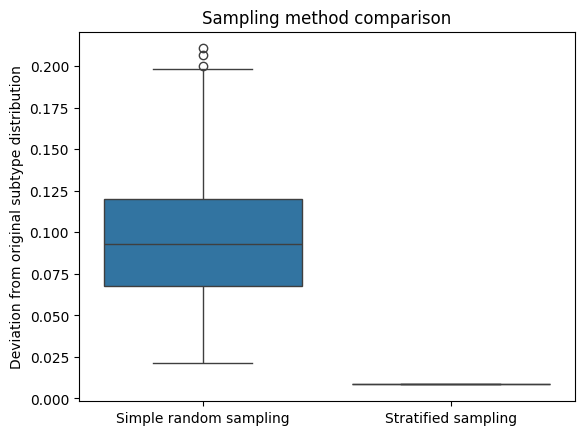

In [31]:
#visuell darstellen

error_df = pd.DataFrame({
    "Simple random sampling": simple_errors,
    "Stratified sampling": strat_errors
})

sns.boxplot(data=error_df)
plt.ylabel("Deviation from original subtype distribution")
plt.title("Sampling method comparison")
plt.show()

### Train/Test-Split

In [32]:
# Features und Labels
X = analysis.drop(columns=["BRCA_subtype"])
y = analysis["BRCA_subtype"]

In [33]:
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #sorgt für rpoduzierbarkeit
    stratify=y #sampling art
)
#20 % test daten
#80% trainingsdaten

In [34]:
# Shapes kontrollieren
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (760, 16162)
X_test: (190, 16162)
y_train: (760,)
y_test: (190,)


In [35]:
#ob die Verteilungen ähnlich geblieben ist
print(y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

BRCA_subtype
LumA      0.455789
LumB      0.202105
Basal     0.146316
Normal    0.125263
Her2      0.070526
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.455263
LumB      0.202632
Basal     0.146053
Normal    0.125000
Her2      0.071053
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.457895
LumB      0.200000
Basal     0.147368
Normal    0.126316
Her2      0.068421
Name: proportion, dtype: float64


## Feature Selection

Während Splitting können neue Gene konstant werden

In [36]:
pipe_anova_logreg = Pipeline([
    ("variance", VarianceThreshold()),          #removes train-constant genes
    ("select", SelectKBest(score_func=f_classif, k=500)),  #selects top 500 genes
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_anova_logreg.fit(X_train, y_train)

pred_anova_logreg = pipe_anova_logreg.predict(X_test)

print(classification_report(y_test, pred_anova_logreg))

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.85      0.85      0.85        13
        LumA       0.92      0.91      0.91        87
        LumB       0.83      0.89      0.86        38
      Normal       0.92      0.92      0.92        24

    accuracy                           0.91       190
   macro avg       0.90      0.90      0.90       190
weighted avg       0.91      0.91      0.91       190



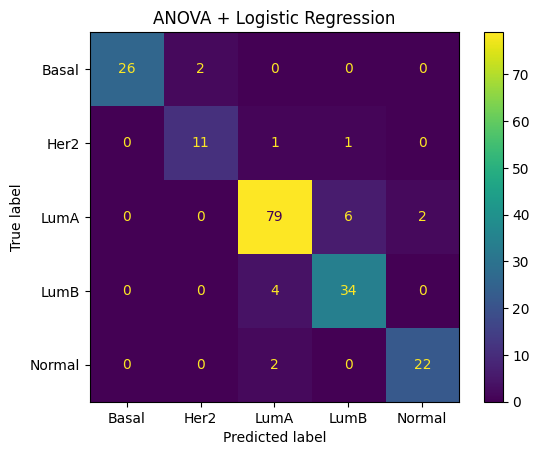

In [37]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, pred_anova_logreg)
plt.title("ANOVA + Logistic Regression")
plt.show()

#eventuell noch für LumA & LumB  optimieren

## Selected Genes ???

In [38]:
# get mask of selected features
selected_mask = pipe_anova_logreg.named_steps["select"].get_support()

# apply mask to original column names
selected_genes = X_train.columns[
    pipe_anova_logreg.named_steps["variance"].get_support()
][selected_mask]

selected_genes

Index(['HIF3A', 'LRRTM2', 'CAMKV', 'GTSE1', 'THSD4', 'CHST3', 'CHST2', 'GPSM2',
       'ZNF703', 'CKS1B',
       ...
       'KIAA1370', 'MMRN2', 'WDR67', 'CX3CL1', 'KCNK15', 'OVCH2', 'NCAPD2',
       'SLC6A14', 'FXYD1', 'KDM4B'],
      dtype='str', length=500)

In [39]:
#Baseline Logistic Regression (ohne Feature Selection)

baseline_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print(classification_report(y_test, baseline_pred))



              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.67      0.77      0.71        13
        LumA       0.88      0.90      0.89        87
        LumB       0.76      0.76      0.76        38
      Normal       0.95      0.88      0.91        24

    accuracy                           0.86       190
   macro avg       0.85      0.85      0.85       190
weighted avg       0.87      0.86      0.86       190



In [40]:
# Comparison Table

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")
baseline_her2_recall = recall_score(
    y_test,
    baseline_pred,
    labels=["Her2"],
    average=None
)[0]

print(baseline_accuracy)
print(baseline_macro_f1)
print(baseline_her2_recall)

0.8631578947368421
0.8479627373220049
0.7692307692307693


In [41]:
anova_accuracy = accuracy_score(y_test, pred_anova_logreg)
anova_macro_f1 = f1_score(y_test, pred_anova_logreg, average="macro")
anova_her2_recall = recall_score(
    y_test,
    pred_anova_logreg,
    labels=["Her2"],
    average=None
)[0]

print(anova_accuracy)
print(anova_macro_f1)
print(anova_her2_recall)

0.9052631578947369
0.8999675534284446
0.8461538461538461


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "ANOVA + Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        anova_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        anova_macro_f1
    ],
    "Her2 Recall": [
        baseline_her2_recall,
        anova_her2_recall
    ],
    "Number of Features": [
        X_train.shape[1],
        500
    ]
})

comparison

,Model,Accuracy,Macro F1,Her2 Recall,Number of Features
0,Baseline Logistic Regression,0.863158,0.847963,0.769231,16162
1,ANOVA + Logistic Regression,0.905263,0.899968,0.846154,500


### Hyperparameter Tuning

In [43]:
pipe = Pipeline([
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)), #f_classif/mutual_info_classif
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "select__k": [200, 300, 350, 400, 450, 500, 750, 1000],
    "model__C": [0.01, 0.1, 1, 10],
    #"model__l1_ratio": [0.05, 0.1, 0.3, 0.5, 0.7, 0.9] # Elastic Net Mischung
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1_macro", 
    #nicht balanced accuracy, da wir hier die Performance über alle Klassen hinweg optimieren wollen
    #balanced accuracy würde die Performance der kleinen Klassen überbewerten, da sie im Durchschnitt schlechter ist
    #F1_macro berücksichtigt die Performance über alle Klassen hinweg und ist damit besser
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_k = grid.best_params_["select__k"]
best_C = grid.best_params_["model__C"]

print("Best k:", grid.best_params_["select__k"])
print("Best C:", grid.best_params_["model__C"])
print("Best CV score:", grid.best_score_)

Best k: 400
Best C: 1
Best CV score: 0.9188957266200612


## Model Selection

zu testen:
LogRegCV |
LogRegEN |
RF |
SVM |
?KNN?

### Modelle definieren & trainieren
Mit Pipeline: "Pipeline allows you to sequentially apply a list of transformers to preprocess the data and, if desired, conclude the sequence with a final predictor for predictive modeling."

In [44]:
PREPROCESSING = [
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(score_func=f_classif, k=best_k)),
    ("scaler",   StandardScaler()),
]

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



#### 1) Logistic Regression mit L2-Regularisierung

In [45]:
# ── 1) Logistic Regression L2 ────────────────────────────────────────────────
pipe_lr = Pipeline(PREPROCESSING + [
    ("model", LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 8),
        cv=5,
        penalty="l2",
        solver="lbfgs",
        scoring="balanced_accuracy",
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Trainiere LogReg L2 ...")
pipe_lr.fit(X_train, y_train)
print(f"  Bestes C: {pipe_lr.named_steps['model'].C_[0]:.4f}")
print("  Fertig.\n")

Trainiere LogReg L2 ...


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=

  Bestes C: 0.0139
  Fertig.



#### 2) Logistic Regression mit Elastic Net

In [46]:
# ── 2) Logistic Regression Elastic Net ───────────────────────────────────────
pipe_en = Pipeline(PREPROCESSING + [
    ("model", LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 8),
        cv=5,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.5, 0.9],
        scoring="balanced_accuracy",
        class_weight="balanced",
        max_iter=3000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Trainiere Elastic Net ...")
pipe_en.fit(X_train, y_train)
print(f"  Bestes C:        {pipe_en.named_steps['model'].C_[0]:.4f}")
print(f"  Bestes l1_ratio: {pipe_en.named_steps['model'].l1_ratio_[0]:.2f}")
print("  Fertig.\n")

Trainiere Elastic Net ...


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


  Bestes C:        0.1931
  Bestes l1_ratio: 0.10
  Fertig.



#### 3) Random Forest

In [47]:
# ── 3) Random Forest ─────────────────────────────────────────────────────────
pipe_rf = Pipeline(PREPROCESSING + [
    ("model", RandomForestClassifier(
        n_estimators=best_k,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Trainiere Random Forest ...")
pipe_rf.fit(X_train, y_train)
print("  Fertig.\n")

Trainiere Random Forest ...
  Fertig.



#### 4) Support Vector Machine

In [48]:
# ── 4) SVM (GridSearchCV über C) ─────────────────────────────────────────────
base_svm = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

pipe_svm = Pipeline(PREPROCESSING + [
    ("model", GridSearchCV(
        estimator=base_svm,
        param_grid={"C": [0.001, 0.01, 0.1, 1, 10]},
        cv=cv_strategy,
        scoring="balanced_accuracy",
        n_jobs=-1,
        verbose=1
    ))
])

print("Trainiere SVM (GridSearchCV über C) ...")
pipe_svm.fit(X_train, y_train)
print(f"  Bestes C:        {pipe_svm.named_steps['model'].best_params_['C']}")
print(f"  Bestes CV-Score: {pipe_svm.named_steps['model'].best_score_:.4f}")
print("  Fertig.\n")

Trainiere SVM (GridSearchCV über C) ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
  Bestes C:        0.01
  Bestes CV-Score: 0.9284
  Fertig.



### Evaluation auf dem Testset

In [49]:
# ── Alle Modelle evaluieren ────────────────────────────────────────────────
# Balanced Accuracy: Mittelwert der Recall-Werte pro Klasse --> berücksichtigt die Imbalance
# Wir sammeln Vorhersagen und Metriken für alle 4 Modelle in einem Dictionary

# ── Evaluation auf dem Testset ───────────────────────────────────────────────
pipelines = {
    "LogReg L2":     pipe_lr,
    "Elastic Net":   pipe_en,
    "Random Forest": pipe_rf,
    "SVM (linear)":  pipe_svm,
}

results = {}

for name, pipe in pipelines.items():
    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f"{'─'*55}")
    y_pred = pipe.predict(X_test)
    ba = balanced_accuracy_score(y_test, y_pred)
    results[name] = {"pipe": pipe, "y_pred": y_pred, "balanced_acc": ba}
    print(f"Balanced Accuracy: {ba:.4f}\n")
    print(classification_report(y_test, y_pred))



───────────────────────────────────────────────────────
 LogReg L2
───────────────────────────────────────────────────────
Balanced Accuracy: 0.9004

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.80      0.92      0.86        13
        LumA       0.94      0.84      0.88        87
        LumB       0.76      0.89      0.82        38
      Normal       0.85      0.92      0.88        24

    accuracy                           0.88       190
   macro avg       0.87      0.90      0.88       190
weighted avg       0.89      0.88      0.88       190


───────────────────────────────────────────────────────
 Elastic Net
───────────────────────────────────────────────────────
Balanced Accuracy: 0.9036

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.86      0.92      0.89        13
        LumA       0.93      0.90      0.91 

### Übersicht & bestes Modell

In [50]:
# ── Vergleichstabelle ────────────────────────────────────────────────────────
comparison = (
    pd.DataFrame({
        "Modell":            list(results.keys()),
        "Balanced Accuracy": [v["balanced_acc"] for v in results.values()],
        "Her2 Recall": [recall_score(y_test, v["y_pred"], labels=["Her2"], average=None)[0] for v in results.values()]
    })
    .sort_values("Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
)
comparison.index += 1
comparison.index.name = "Rang"
print("\n" + "═"*45)
print(" MODELLVERGLEICH – Balanced Accuracy")
print("═"*45)
print(comparison.to_string())

best_model = comparison.iloc[0]["Modell"]
best_res  = results[best_model]["pipe"].named_steps["model"]
best_acc  = results[best_model]["balanced_acc"]
recall = recall_score(y_test, results[best_model]["y_pred"], average=None, labels=best_res.classes_)

print(f"\n→ Bestes Modell: {best_model} ({best_acc:.4f}) | Her2 Recall: {recall[best_res.classes_ == 'Her2'][0]:.4f})")


═════════════════════════════════════════════
 MODELLVERGLEICH – Balanced Accuracy
═════════════════════════════════════════════
             Modell  Balanced Accuracy  Her2 Recall
Rang                                               
1       Elastic Net           0.903587     0.923077
2         LogReg L2           0.900426     0.923077
3      SVM (linear)           0.884376     0.846154
4     Random Forest           0.793282     0.461538

→ Bestes Modell: Elastic Net (0.9036) | Her2 Recall: 0.9231)


#### Confusion Matrices aller Modelle

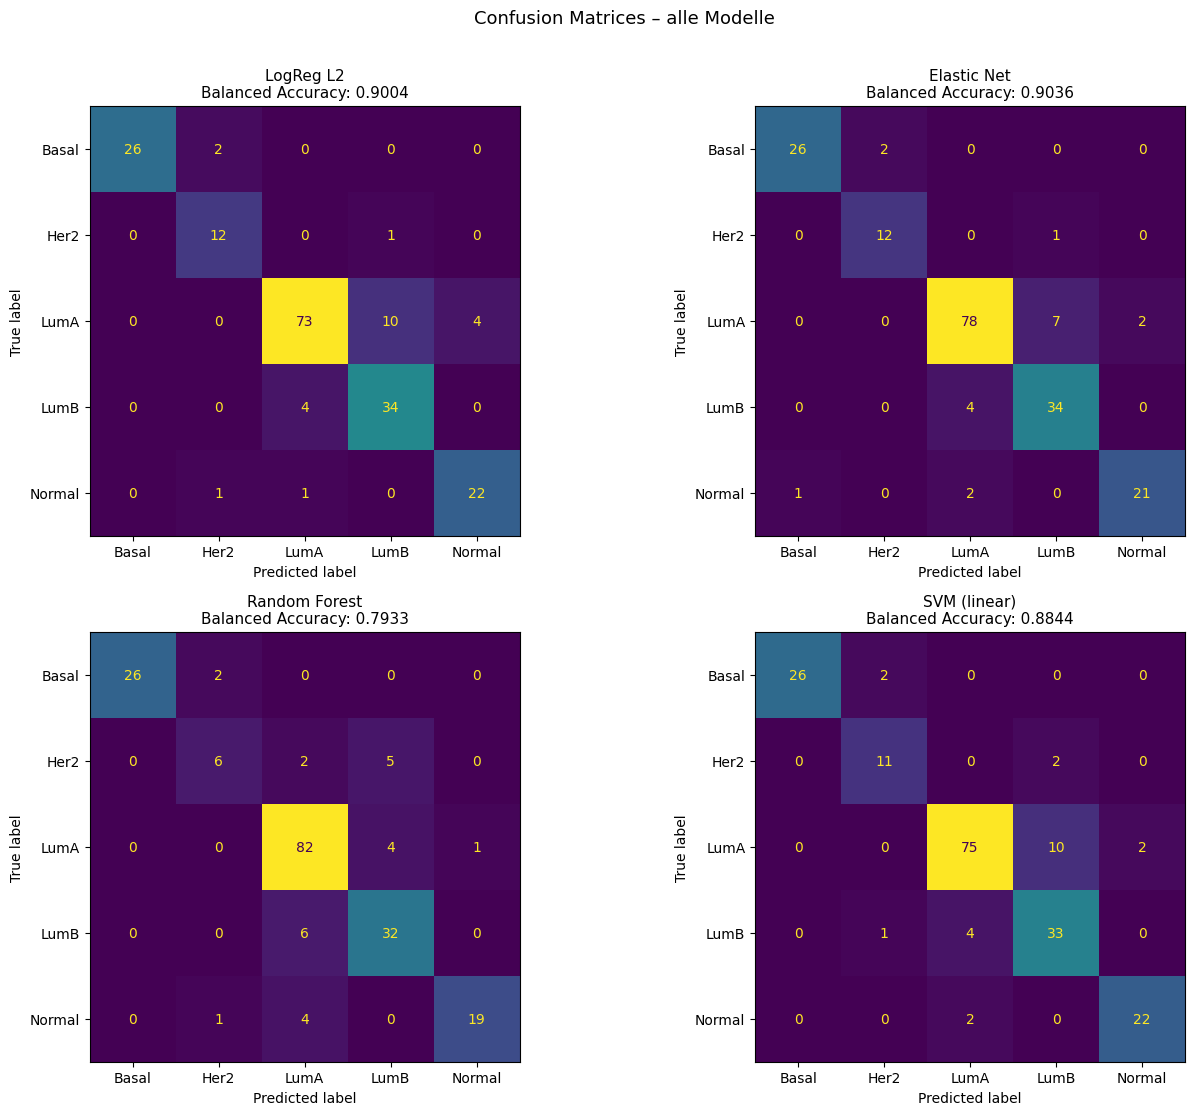

In [51]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
classes = best_res.classes_

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(f"{name}\nBalanced Accuracy: {res['balanced_acc']:.4f}", fontsize=11)

plt.suptitle("Confusion Matrices – alle Modelle", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Feature Importance --> Wichtigste Gene

Je nach Modelltyp unterscheidet sich die Interpretation:
- **LogReg / Elastic Net**: Koeffizienten zeigen, welche Gene für welchen Subtyp sprechen
- **Random Forest**: Feature Importance (Gini) zeigt globale Wichtigkeit über alle Subtypen
- **SVM**: Koeffizientenvektor des linearen Kernels (entspricht den Gewichten der Hyperebene)

In [52]:
# ── Feature Importance des besten Modells ─────────────────────────────────
best_name  = comparison.iloc[0]["Modell"]          # z.B. "Elastic Net"
best_pipe  = results[best_name]["pipe"]             # die ganze Pipeline
best_clf   = best_pipe.named_steps["model"]         # nur der Classifier

# Gennamen nach VarianceThreshold + SelectKBest rekonstruieren
var_mask    = best_pipe.named_steps["variance"].get_support()
select_mask = best_pipe.named_steps["select"].get_support()
selected_genes = X_train.columns[var_mask][select_mask]

print(f"Feature-Analyse für: {best_name}\n")

if best_name in ("LogReg L2", "Elastic Net"):
    coef_df = pd.DataFrame(
        best_clf.coef_,
        index=best_clf.classes_,
        columns=selected_genes
    )
    print("Top 5 Gene pro Subtyp (nach absolutem Koeffizienten):")
    for subtype in best_clf.classes_:
        top5 = coef_df.loc[subtype].abs().sort_values(ascending=False).head(5)
        print(f"  {subtype}: {list(top5.index)}")

elif best_name == "Random Forest":
    importances = pd.Series(
        best_clf.feature_importances_,
        index=selected_genes
    ).sort_values(ascending=False)
    print("Top 10 Gene (Random Forest Feature Importance):")
    print(importances.head(10).to_string())

elif best_name == "SVM (linear)":
    # best_clf ist hier ein GridSearchCV-Objekt → .best_estimator_ holt die SVC
    svc = best_clf.best_estimator_
    coef_df = pd.DataFrame(svc.coef_, columns=selected_genes)
    print("Top 5 Gene mit grössten absoluten SVM-Gewichten (alle Klassen):")
    top_genes = coef_df.abs().max(axis=0).sort_values(ascending=False).head(5)
    print(top_genes.to_string())


Feature-Analyse für: Elastic Net

Top 5 Gene pro Subtyp (nach absolutem Koeffizienten):
  Basal: ['ZNF454', 'FOXC1', 'GDF5', 'GFRA3', 'ATL2']
  Her2: ['ESR1', 'FLJ45983', 'TRIM3', 'CCDC125', 'C6orf97']
  LumA: ['BCL2', 'RANBP1', 'NAT1', 'PIF1', 'FOXC1']
  LumB: ['PPP1R14C', 'SCUBE2', 'GFAP', 'C6orf97', 'PDGFD']
  Normal: ['OXTR', 'GLRA4', 'KCNMB1', 'CNN1', 'NAT1']


## Bestes Modell trainieren

aufpassen, dass Testset noch nicht gesehen
möglicherweise mit crossvalidation verbessern?
--> neues modell


Warum ein neues Modell und nicht einfach pipe_en verwenden?
 → Im Modellvergleich haben wir die Testset-Metriken aller 4 Modelle gesehen und anhand davon Elastic Net ausgewählt. Damit sind die Testdaten indirekt in die Modellauswahl eingeflossen (sog. "implicit leakage"). --> Um eine wirklich unverfälschte finale Zahl zu erhalten, setzen wir das Modell neu auf – mit denselben Hyperparametern, aber so, als hätten wir die Testdaten nie gesehen.

Woher kommen die Hyperparameter (C, l1_ratio)?
--> pipe_en hat intern via 5-Fold Cross Validation auf X_train die besten Werte gesucht. Diese CV-Ergebnisse sind sauber (kein Testset involviert), daher übernehmen wir C und l1_ratio direkt daraus.

In [53]:
# Beste Hyperparameter aus dem CV-Vergleich auslesen
# pipe_en.named_steps["model"] ist das LogisticRegressionCV-Objekt
best_C        = results["Elastic Net"]["pipe"].named_steps["model"].C_[0]
best_l1_ratio = results["Elastic Net"]["pipe"].named_steps["model"].l1_ratio_[0]

print(f"Übernommene Hyperparameter aus CV:")
print(f"  C        = {best_C:.4f}")
print(f"  l1_ratio = {best_l1_ratio:.2f}")
print()


Übernommene Hyperparameter aus CV:
  C        = 0.1931
  l1_ratio = 0.10



In [54]:
# ── Finales Modell definieren ─────────────────────────────────────────────────
# Identisches Preprocessing wie im Vergleich (VarianceThreshold → SelectKBest → Scaler)
# Jetzt aber LogisticRegression (nicht CV-Variante), weil die Hyperparameter
# bereits feststehen und nicht mehr gesucht werden müssen.

final_pipe = Pipeline([
    ("variance", VarianceThreshold()),                          # entfernt konstante Gene
    ("select",   SelectKBest(score_func=f_classif, k=500)),    # top k Gene via ANOVA
    ("scaler",   StandardScaler()),                             # z-Standardisierung
    ("model",    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=best_C,                  # bestes C aus CV
        l1_ratio=best_l1_ratio,    # bestes l1_ratio aus CV
        class_weight="balanced",   # kompensiert Klassenimbalanz (Her2 selten)
        max_iter=3000,
        random_state=42
    ))
])

In [55]:
# ── Training ausschliesslich auf Trainingsdaten ───────────────────────────────
# X_train / y_train: die 80 % die das Modell sehen darf.
# X_test  / y_test:  werden erst im nächsten Schritt verwendet – einmalig.
print("Trainiere finales Modell auf X_train ...")
final_pipe.fit(X_train, y_train)
print("  Fertig.\n")

final_pred_train = final_pipe.predict(X_train)

Trainiere finales Modell auf X_train ...


c:\Users\niels\miniconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Fertig.



In [56]:
# ── Einmalige Evaluation auf dem Testset ─────────────────────────────────────
# Dies ist die einzige und letzte Berührung mit den Testdaten.
# Die resultierende Balanced Accuracy ist die offizielle finale Modellleistung.
final_pred_test = final_pipe.predict(X_test)
final_ba   = balanced_accuracy_score(y_test, final_pred_test)
final_accuracy = accuracy_score(y_test, final_pred_test)

print("══════════════════════════════════════════════")
print(" FINALES MODELL --- Evaluation auf dem Testset")
print("══════════════════════════════════════════════")
print(f"Balanced Accuracy: {final_ba:.4f}")
print(f"Accuracy: {final_accuracy:.4f}\n")
print(classification_report(y_test, final_pred_test))

══════════════════════════════════════════════
 FINALES MODELL --- Evaluation auf dem Testset
══════════════════════════════════════════════
Balanced Accuracy: 0.9029
Accuracy: 0.9053

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.80      0.92      0.86        13
        LumA       0.93      0.92      0.92        87
        LumB       0.85      0.87      0.86        38
      Normal       0.91      0.88      0.89        24

    accuracy                           0.91       190
   macro avg       0.89      0.90      0.90       190
weighted avg       0.91      0.91      0.91       190



### hierarchischer Classifier

Wird auf den selben Daten trainiert wie das eigentliche Modell --> gleiche Ergebnisse --> useless

In [57]:
# ── Hierarchischer Classifier ─────────────────────────────────────────────────
# Idee: bei unsicheren LumA/LumB-Vorhersagen übernimmt ein spezialisierter
# binärer Classifier. In der Praxis zeigt sich, ob das einen Unterschied macht.

# Spezialisierter LumA vs. LumB Classifier
lum_mask = y_train.isin(["LumA", "LumB"])
X_lum    = X_train[lum_mask]
y_lum    = y_train[lum_mask]

lum_pipe = Pipeline([
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(f_classif, k=best_k)),
    ("scaler",   StandardScaler()),
    ("model",    LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

lum_pipe.fit(X_lum, y_lum)

# Hierarchische Vorhersage
def predict_hierarchical(X, main_pipe, lum_pipe, threshold=0.6):
    main_proba   = main_pipe.predict_proba(X)
    main_classes = main_pipe.classes_
    hier_pred    = main_pipe.predict(X).tolist()

    lum_a_idx = list(main_classes).index("LumA")
    lum_b_idx = list(main_classes).index("LumB")

    for i, pred in enumerate(hier_pred):
        if pred in ["LumA", "LumB"]:
            p_luma = main_proba[i][lum_a_idx]
            p_lumb = main_proba[i][lum_b_idx]
            lum_confidence = max(p_luma, p_lumb) / (p_luma + p_lumb)

            if lum_confidence < threshold:
                hier_pred[i] = lum_pipe.predict(X.iloc[[i]])[0]

    return hier_pred

hier_pred  = predict_hierarchical(X_test, final_pipe, lum_pipe, threshold=0.6)
hier_ba    = balanced_accuracy_score(y_test, hier_pred)

# ── Vergleich ─────────────────────────────────────────────────────────────────
print("══════════════════════════════════════════════════════")
print(" HIERARCHISCHER CLASSIFIER vs. FINALES MODELL")
print("══════════════════════════════════════════════════════")
print(f"  Finales Modell (Elastic Net): {final_ba:.4f}")
print(f"  Hierarchischer Classifier:    {hier_ba:.4f}")
print(f"  Differenz:                   {hier_ba - final_ba:+.4f}")
print()
print(classification_report(y_test, hier_pred))

══════════════════════════════════════════════════════
 HIERARCHISCHER CLASSIFIER vs. FINALES MODELL
══════════════════════════════════════════════════════
  Finales Modell (Elastic Net): 0.9029
  Hierarchischer Classifier:    0.9029
  Differenz:                   +0.0000

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.80      0.92      0.86        13
        LumA       0.93      0.92      0.92        87
        LumB       0.85      0.87      0.86        38
      Normal       0.91      0.88      0.89        24

    accuracy                           0.91       190
   macro avg       0.89      0.90      0.90       190
weighted avg       0.91      0.91      0.91       190



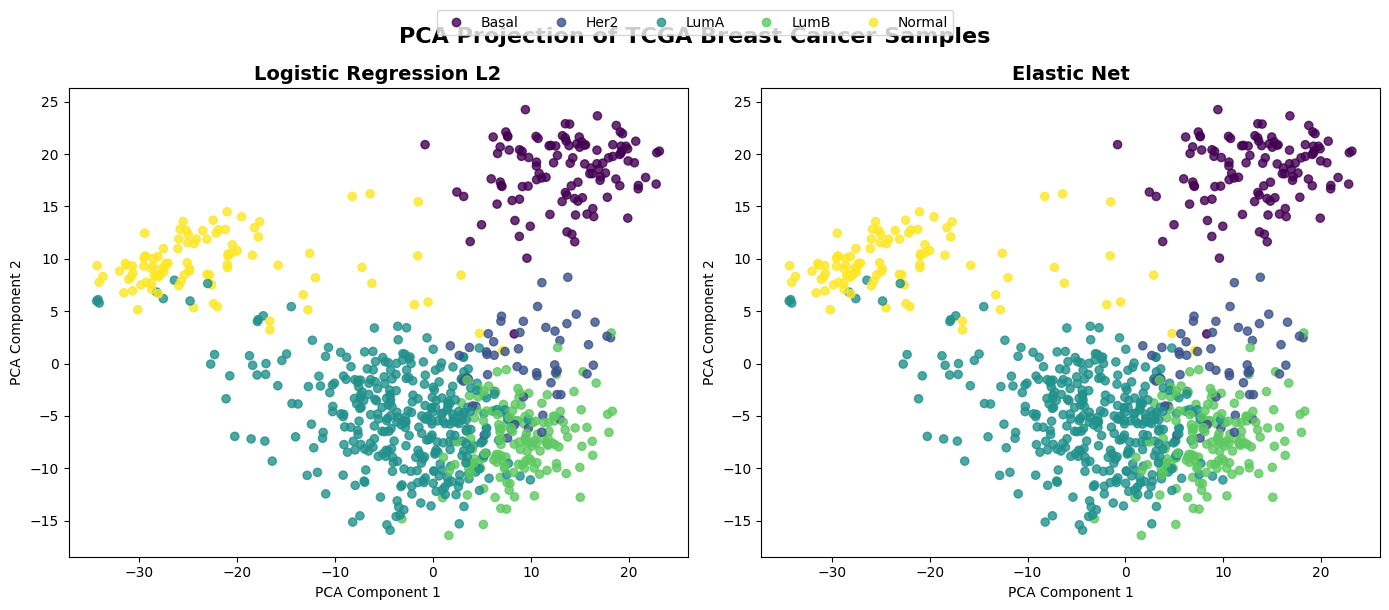

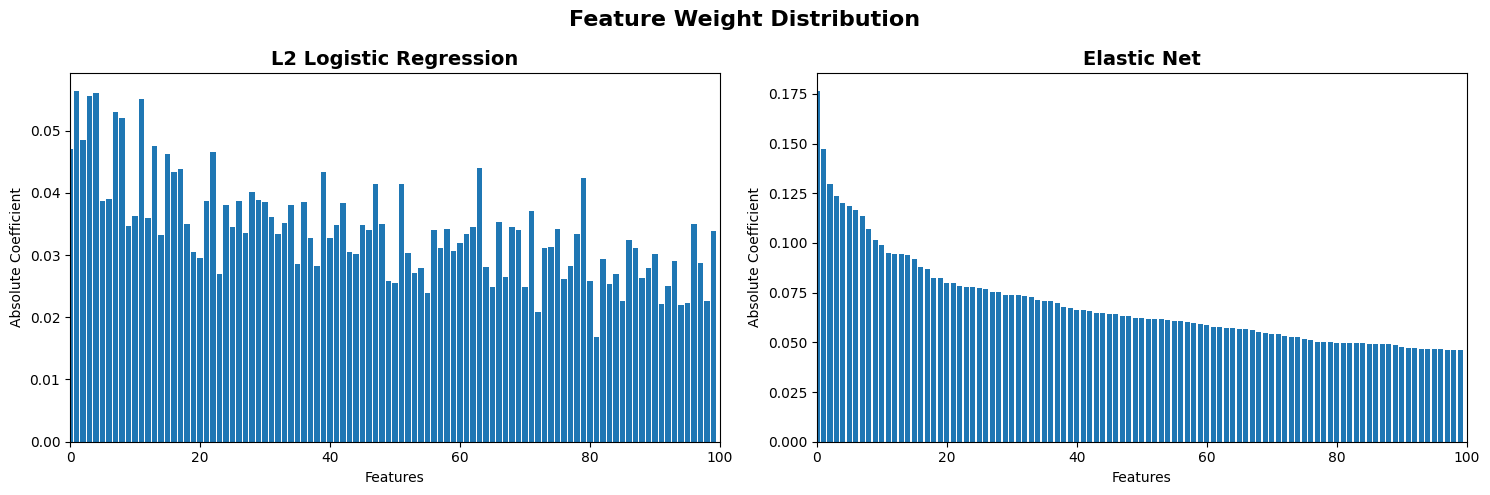

═══════════════════════════════════════
Nicht-Null Koeffizienten
═══════════════════════════════════════
L2 Logistic Regression : 400
Elastic Net            : 373

Interpretation:
- L2 nutzt fast alle Features
- Elastic Net entfernt viele irrelevante Gene
- Dadurch weniger Overfitting und bessere Generalisierung


In [58]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALISIERUNG: L2 vs Elastic Net
# - verwendet automatisch deine bereits trainierten Modelle
# - keine Variablenanpassung nötig
# - erzeugt:
#   1) PCA-Projektion mit Modellvorhersagen
#   2) Koeffizientenvergleich (L2 vs Elastic Net)
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ──────────────────────────────────────────────────────────────────────────────
# Modelle laden
# ──────────────────────────────────────────────────────────────────────────────

l2_pipe = results["LogReg L2"]["pipe"]
en_pipe = results["Elastic Net"]["pipe"]

# ──────────────────────────────────────────────────────────────────────────────
# PREPROCESSING auf Trainingsdaten anwenden
# ──────────────────────────────────────────────────────────────────────────────

def transform_features(pipe, X):
    X_var = pipe.named_steps["variance"].transform(X)
    X_sel = pipe.named_steps["select"].transform(X_var)
    X_scl = pipe.named_steps["scaler"].transform(X_sel)
    return X_scl

X_l2 = transform_features(l2_pipe, X_train)
X_en = transform_features(en_pipe, X_train)

# Labels numerisch kodieren für Farben
classes = np.unique(y_train)
class_to_int = {c: i for i, c in enumerate(classes)}
y_num = np.array([class_to_int[c] for c in y_train])

# ──────────────────────────────────────────────────────────────────────────────
# PCA auf 2D
# ──────────────────────────────────────────────────────────────────────────────

pca = PCA(n_components=2, random_state=42)

X_l2_pca = pca.fit_transform(X_l2)
X_en_pca = pca.fit_transform(X_en)

# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 1: PCA-Projektion
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_l2_pca[:, 0],
    X_l2_pca[:, 1],
    c=y_num,
    s=35,
    alpha=0.8
)

axes[0].set_title("Logistic Regression L2", fontsize=14, weight="bold")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

scatter2 = axes[1].scatter(
    X_en_pca[:, 0],
    X_en_pca[:, 1],
    c=y_num,
    s=35,
    alpha=0.8
)

axes[1].set_title("Elastic Net", fontsize=14, weight="bold")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

# gemeinsame Legende
handles = scatter2.legend_elements()[0]
fig.legend(
    handles,
    classes,
    loc="upper center",
    ncol=len(classes),
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "PCA Projection of TCGA Breast Cancer Samples",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 2: Koeffizientenvergleich
# ──────────────────────────────────────────────────────────────────────────────

# Koeffizienten mitteln über Klassen
l2_coef = np.mean(np.abs(l2_pipe.named_steps["model"].coef_), axis=0)
en_coef = np.mean(np.abs(en_pipe.named_steps["model"].coef_), axis=0)

# Anzahl Features
n_features = len(l2_coef)

# Sortierung nach Elastic Net Wichtigkeit
sort_idx = np.argsort(en_coef)[::-1]

l2_sorted = l2_coef[sort_idx]
en_sorted = en_coef[sort_idx]

# Optional nur Top Features zeigen
top_n = min(100, n_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# L2
axes[0].bar(
    np.arange(top_n),
    l2_sorted[:top_n]
)

axes[0].set_title("L2 Logistic Regression", fontsize=14, weight="bold")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Absolute Coefficient")
axes[0].set_xlim(0, top_n)

# Elastic Net
axes[1].bar(
    np.arange(top_n),
    en_sorted[:top_n]
)

axes[1].set_title("Elastic Net", fontsize=14, weight="bold")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Absolute Coefficient")
axes[1].set_xlim(0, top_n)

plt.suptitle(
    "Feature Weight Distribution",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Zusätzliche Statistik
# ──────────────────────────────────────────────────────────────────────────────

l2_nonzero = np.sum(l2_coef > 1e-6)
en_nonzero = np.sum(en_coef > 1e-6)

print("═══════════════════════════════════════")
print("Nicht-Null Koeffizienten")
print("═══════════════════════════════════════")
print(f"L2 Logistic Regression : {l2_nonzero}")
print(f"Elastic Net            : {en_nonzero}")

print("\nInterpretation:")
print("- L2 nutzt fast alle Features")
print("- Elastic Net entfernt viele irrelevante Gene")
print("- Dadurch weniger Overfitting und bessere Generalisierung")

## Model Analysis & Interpretation

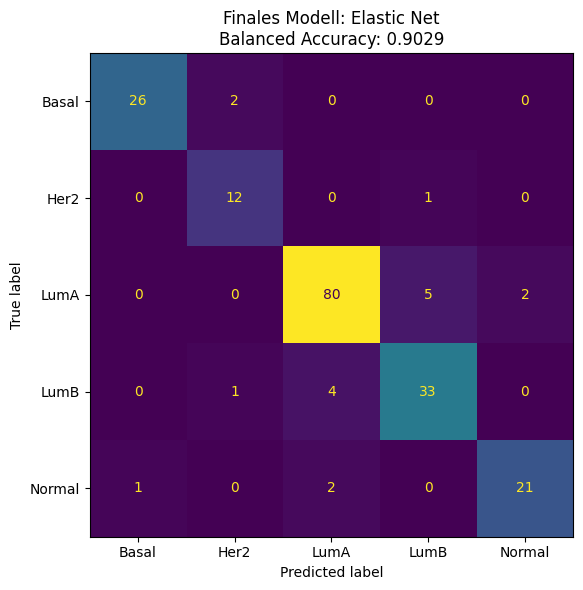

In [60]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred_test,
    ax=ax,
    colorbar=False
)
ax.set_title(
    f"Finales Modell: Elastic Net\nBalanced Accuracy: {final_ba:.4f}",
    fontsize=12
)
plt.tight_layout()
plt.show()

In [61]:
def compute_metrics(y_true, y_pred, dataset_name):
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

train_metrics = compute_metrics(y_train, final_pred_train, "Train")
test_metrics = compute_metrics(y_test, final_pred_test, "Test")

train_test_comparison = pd.DataFrame([train_metrics, test_metrics])

# Add generalization gap
gap = train_test_comparison.iloc[0, 1:] - train_test_comparison.iloc[1, 1:]
gap_row = pd.DataFrame([["Gap: Train - Test"] + list(gap)], columns=train_test_comparison.columns)

train_test_comparison = pd.concat(
    [train_test_comparison, gap_row],
    ignore_index=True
)

train_test_comparison

,Dataset,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Train,0.997368,0.998844,0.997436,0.998844,0.998130,0.997373
1,Test,0.905263,0.902922,0.890479,0.902922,0.895643,0.905770
2,Gap: Train - Test,0.092105,0.095922,0.106957,0.095922,0.102487,0.091603


In [62]:
train_report = classification_report(
    y_train,
    final_pred_train,
    output_dict=True,
    zero_division=0
)

test_report = classification_report(
    y_test,
    final_pred_test,
    output_dict=True,
    zero_division=0
)

per_class_recall = pd.DataFrame({
    "Class": classes,
    "Train Recall": [train_report[cls]["recall"] for cls in classes],
    "Test Recall": [test_report[cls]["recall"] for cls in classes],
})

per_class_recall["Recall Gap"] = (
    per_class_recall["Train Recall"] - per_class_recall["Test Recall"]
)

per_class_recall

,Class,Train Recall,Test Recall,Recall Gap
0,Basal,1.00000,0.928571,0.071429
1,Her2,1.00000,0.923077,0.076923
2,LumA,0.99422,0.919540,0.074679
3,LumB,1.00000,0.868421,0.131579
4,Normal,1.00000,0.875000,0.125000


In [63]:
train_report = classification_report(
    y_train,
    final_pred_train,
    output_dict=True,
    zero_division=0
)

test_report = classification_report(
    y_test,
    final_pred_test,
    output_dict=True,
    zero_division=0
)

per_class_recall = pd.DataFrame({
    "Class": classes,
    "Train Recall": [train_report[cls]["recall"] for cls in classes],
    "Test Recall": [test_report[cls]["recall"] for cls in classes],
})

per_class_recall["Recall Gap"] = (
    per_class_recall["Train Recall"] - per_class_recall["Test Recall"]
)

per_class_recall

,Class,Train Recall,Test Recall,Recall Gap
0,Basal,1.00000,0.928571,0.071429
1,Her2,1.00000,0.923077,0.076923
2,LumA,0.99422,0.919540,0.074679
3,LumB,1.00000,0.868421,0.131579
4,Normal,1.00000,0.875000,0.125000


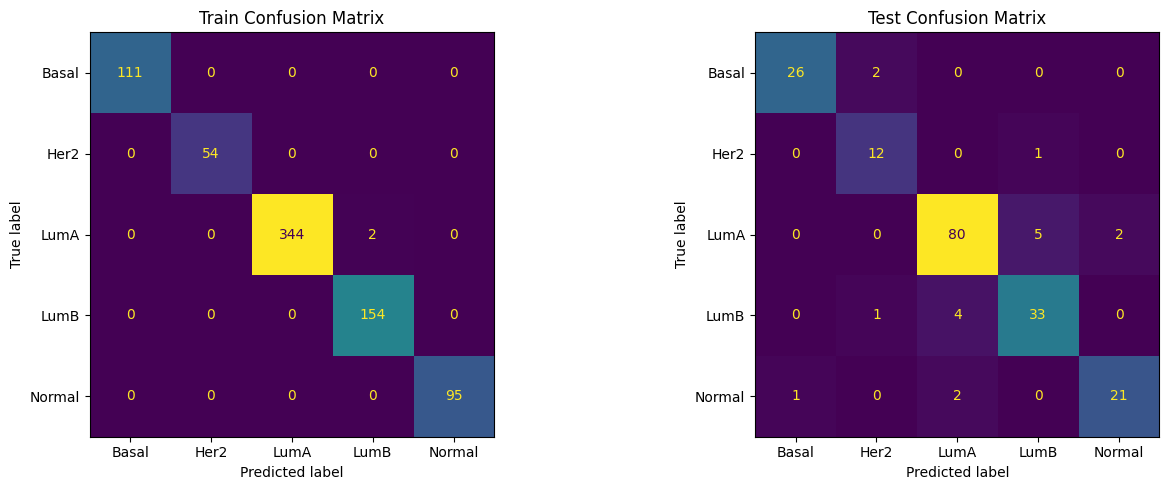

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train, final_pred_train, labels=classes)
cm_test = confusion_matrix(y_test, final_pred_test, labels=classes)

ConfusionMatrixDisplay(cm_train, display_labels=classes).plot(
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test, display_labels=classes).plot(
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
def bootstrap_metric_ci(
    y_true,
    y_pred,
    y_proba,
    classes,
    n_bootstraps=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    records = []

    for b in range(n_bootstraps):
        idx = rng.choice(
            np.arange(len(y_true)),
            size=len(y_true),
            replace=True
        )

        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]
        y_proba_b = y_proba[idx]

        # Skip bootstrap samples missing classes for ROC-AUC
        y_true_bin_b = label_binarize(y_true_b, classes=classes)

        metric_values = {
            "Accuracy": accuracy_score(y_true_b, y_pred_b),
            "Balanced Accuracy": balanced_accuracy_score(y_true_b, y_pred_b),
            "Macro Precision": precision_score(y_true_b, y_pred_b, average="macro", zero_division=0),
            "Macro Recall": recall_score(y_true_b, y_pred_b, average="macro", zero_division=0),
            "Macro F1": f1_score(y_true_b, y_pred_b, average="macro", zero_division=0),
            "Weighted F1": f1_score(y_true_b, y_pred_b, average="weighted", zero_division=0),
        }

        try:
            metric_values["Macro ROC-AUC OvR"] = roc_auc_score(
                y_true_bin_b,
                y_proba_b,
                average="macro",
                multi_class="ovr"
            )
        except ValueError:
            metric_values["Macro ROC-AUC OvR"] = np.nan

        # Her2-specific recall if Her2 exists
        if "Her2" in classes:
            her2_true = (y_true_b == "Her2")
            her2_pred = (y_pred_b == "Her2")

            if her2_true.sum() > 0:
                metric_values["Her2 Recall"] = recall_score(
                    her2_true,
                    her2_pred,
                    zero_division=0
                )
            else:
                metric_values["Her2 Recall"] = np.nan

        records.append(metric_values)

    boot_df = pd.DataFrame(records)

    summary = []

    for metric in boot_df.columns:
        values = boot_df[metric].dropna()

        summary.append({
            "Metric": metric,
            "Mean": values.mean(),
            "Std": values.std(),
            "CI 2.5%": np.percentile(values, 2.5),
            "CI 97.5%": np.percentile(values, 97.5),
            "N valid bootstraps": len(values)
        })

    return pd.DataFrame(summary)


y_test_proba = results["Elastic Net"]["pipe"].predict_proba(X_test)

bootstrap_ci_table = bootstrap_metric_ci(
    y_true=y_test,
    y_pred=final_pred_test,
    y_proba=y_test_proba,
    classes=classes,
    n_bootstraps=1000,
    random_state=42
)

bootstrap_ci_table

bootstrap_ci_table

,Metric,Mean,Std,CI 2.5%,CI 97.5%,N valid bootstraps
0,Accuracy,0.904653,0.021184,0.863158,0.942105,1000
1,Balanced Accuracy,0.902361,0.025095,0.851322,0.947301,1000
2,Macro Precision,0.889835,0.028456,0.832767,0.940746,1000
3,Macro Recall,0.902361,0.025095,0.851322,0.947301,1000
4,Macro F1,0.893032,0.026090,0.839975,0.939539,1000
5,Weighted F1,0.905305,0.020952,0.862832,0.943185,1000
6,Macro ROC-AUC OvR,0.983805,0.005030,0.972873,0.992750,1000
7,Her2 Recall,0.921476,0.074575,0.750000,1.000000,1000
